# 06-Serverless Containers (ECR & AWS Fargate) - Simulated Architecture

In Lesson 05, we engineered Event-Driven Compute using AWS Lambda and SQS. We decoupled our architecture and achieved high-throughput, serverless scaling.

However, AWS Lambda has strict physical limits governed by its underlying MicroVM architecture:

1. **The Time Limit:** A Lambda function mathematically terminates after exactly 15 minutes (900 seconds).
2. **The Space Limit:** The maximum deployment package size is 250 MB unzipped.
3. **The Compute Limit:** You are capped at 10 GB of RAM and cannot easily attach dedicated heavy compute layers or massive dependency matrices.

If you are a Machine Learning Engineer trying to load a 4 GB PyTorch LLM into memory and run an inference job that takes 45 minutes, AWS Lambda will violently fail.

To bypass these limits, we engineer **Serverless Containers**. We package our runtime environment into an immutable **Docker** image, push it to an **Elastic Container Registry (ECR)**, and command the **Elastic Container Service (ECS) via AWS Fargate** to autonomously run the task.

Let's boot our simulation environment to engineer heavy-duty serverless containers.


In [5]:
# Required installations: pip install boto3 matplotlib seaborn
import boto3
from botocore.exceptions import ClientError
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Fargate Simulation Engine Initialized.")

✅ Systems Architecture & Fargate Simulation Engine Initialized.


# 1. The Mathematics of Immutable Containers & Fargate Physics

### The Docker Container ($\mathcal{C}$)

A Docker container is a mathematically isolated process running on a host OS. It uses Linux namespaces and `cgroups` (Control Groups) to restrict hardware access and isolate the file system.


$$\mathcal{C} = \langle \text{Base OS}, \text{Dependencies}, \text{Application Code} \rangle$$


Because $\mathcal{C}$ is immutable, it completely eliminates environment drift. If it runs on your local workstation, it is mathematically guaranteed to run identically on any target cluster.

### The Fargate Allocation Matrix

In a traditional container cluster, you must provision an underlying pool of servers and play a game of "Bin Packing"—trying to mathematically fit $N$ containers of different sizes onto static physical nodes without wasting resource fragments.

AWS Fargate destroys this complexity. Fargate is a serverless compute engine for containers. You define a Resource Vector $\mathbf{R}$ specifying exact CPU and Memory requirements:


$$\mathbf{R} = \langle \text{vCPU}, \text{RAM} \rangle$$

When you submit $\mathbf{R}$ to the ECS Control Plane, the engine dynamically allocates a hypervisor exclusively for your container, attaches an Elastic Network Interface (ENI) directly into your Subnet topology, runs the task, and instantly terminates the container once execution completes.

# 2. Imperative Execution: Boto3 Container Registries (Simulation)

We will write the exact Boto3 code required to provision an ECR repository. However, we will use a `try/except` block to intercept the LocalStack open-source limitation and gracefully output the local Docker equivalent commands that mathematically simulate the exact same physical constraints.

In [6]:
# --- ⚙️ STEP 1: Initializing ECR & ECS Clients (Local Vector) ---
print("--- 🚀 Initializing ECR & Fargate Imperative Provisioning (Simulation) ---")
boto3.setup_default_session(aws_access_key_id='test', aws_secret_access_key='test', region_name='us-east-1')
local_endpoint = 'http://localhost:4566'

ecr_client = boto3.client('ecr', endpoint_url=local_endpoint)

repo_name = "enterprise-ml-inference-engine"

# --- 📦 STEP 2: Provisioning the Container Registry ---
try:
    print(f"   [API CALL] Allocating ECR Repository: {repo_name}")
    repo_response = ecr_client.create_repository(
        repositoryName=repo_name,
        imageScanningConfiguration={'scanOnPush': True}
    )
    print(f"   ✅ Local ECR Repository Active.")

except ClientError as e:
    # Intercepting the LocalStack Community Edition limitation
    if 'InternalFailure' in str(e) or 'not yet implemented' in str(e):
        print("\n   ⚠️ [LOCALSTACK COMMUNITY LIMITATION DETECTED]")
        print("   -> ECR/ECS is a LocalStack Pro feature. Bypassing API to native Docker Simulation.")
        print(f"   -> SIMULATION: ECR Repository '{repo_name}' conceptually created.")
    else:
        print(f"   [Error]: {str(e)}")

# --- ⚡ STEP 3: Fargate Local Simulation Physics ---
print("\n--- ⚡ Simulating Fargate Hypervisor Physics Locally ---")
print("To mathematically simulate AWS Fargate's Resource Vector R = <4 vCPU, 16GB RAM> on your laptop for $0.00, you execute the following native Docker command:")
print("\n   $ docker run \\")
print("       --cpus=\"4.0\" \\")
print("       --memory=\"16g\" \\")
print("       --rm \\")
print(f"       {repo_name}:latest")

print("\n--- 💡 Engineering Insight ---")
print("The `--rm` flag in Docker perfectly simulates Fargate's serverless termination sequence. The microsecond the Python ML script finishes running inside the container, Docker mathematically annihilates the container from your laptop's memory, ensuring $0.00 ongoing compute waste. You have achieved serverless hypervisor isolation locally.")

--- 🚀 Initializing ECR & Fargate Imperative Provisioning (Simulation) ---
   [API CALL] Allocating ECR Repository: enterprise-ml-inference-engine

   ⚠️ [LOCALSTACK COMMUNITY LIMITATION DETECTED]
   -> ECR/ECS is a LocalStack Pro feature. Bypassing API to native Docker Simulation.
   -> SIMULATION: ECR Repository 'enterprise-ml-inference-engine' conceptually created.

--- ⚡ Simulating Fargate Hypervisor Physics Locally ---
To mathematically simulate AWS Fargate's Resource Vector R = <4 vCPU, 16GB RAM> on your laptop for $0.00, you execute the following native Docker command:

   $ docker run \
       --cpus="4.0" \
       --memory="16g" \
       --rm \
       enterprise-ml-inference-engine:latest

--- 💡 Engineering Insight ---
The `--rm` flag in Docker perfectly simulates Fargate's serverless termination sequence. The microsecond the Python ML script finishes running inside the container, Docker mathematically annihilates the container from your laptop's memory, ensuring $0.00 ongoing 

# 3. Declarative Execution: Terraform Fargate Layout (Plan Mode)

Because the open-source LocalStack container will reject the ECS resource creation, we use Terraform's **`terraform plan`** command.

`terraform plan` computes the mathematical dependency graph, validates your syntax, and proves the architecture is flawless without actually making the physical API calls. This allows us to engineer production-grade IaC for $0.00.

```hcl
# --- 📜 fargate.tf (Declarative Fargate Topology) ---

provider "aws" {
  region                      = "us-east-1"
  access_key                  = "test"
  secret_key                  = "test"
  skip_credentials_validation = true
  skip_metadata_api_check     = true
  skip_requesting_account_id  = true

  endpoints {
    ecs = "http://localhost:4566"
    ecr = "http://localhost:4566"
    iam = "http://localhost:4566"
  }
}

# 1. Define the ECS Control Plane Cluster
resource "aws_ecs_cluster" "ml_cluster" {
  name = "Enterprise-ML-Cluster"
}

# 2. Define the Mechanical Boundaries (Task Definition)
resource "aws_ecs_task_definition" "ml_inference_task" {
  family                   = "ml-inference-worker"
  network_mode             = "awsvpc"             # Mandatory for Fargate (Direct ENI Injection)
  requires_compatibilities = ["FARGATE"]
  cpu                      = "4096"               # 4 vCPU
  memory                   = "16384"              # 16 GB RAM
  execution_role_arn       = "arn:aws:iam::000000000000:role/ecsTaskExecutionRole"
  task_role_arn            = "arn:aws:iam::000000000000:role/ecsTaskRole"

  container_definitions = jsonencode([
    {
      name      = "ml-container"
      image     = "localhost:4566/enterprise-ml-inference-engine:latest"
      essential = true
      
      logConfiguration = {
        logDriver = "awslogs"
        options = {
          "awslogs-group"         = "/ecs/ml-inference"
          "awslogs-region"        = "us-east-1"
          "awslogs-stream-prefix" = "ecs"
        }
      }
    }
  ])
}

# 3. Execute `terraform plan` in your terminal.
# Terraform will successfully output the dependency graph showing the Cluster 
# being built before the Task Definition, validating your logic for $0.00.

```

# 4. Visualizing Fargate Network Injection Topologies

To verify how the serverless execution layer decouples runtime environments while injecting container routing directly into software-defined networks, let's trace the architectural topography.

/tmp/ipykernel_6508/1225307432.py:8: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  aws_cloud_box = patches.Rectangle((0.0, 0.5), 3.5, 8.0, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--')
/tmp/ipykernel_6508/1225307432.py:22: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  vpc_box = patches.Rectangle((4.5, 0.5), 9.0, 8.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2)
/tmp/ipykernel_6508/1225307432.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  sub_a_box = patches.Rectangle((5.0, 2.5), 8.0, 4.5, fill=True, color='#e74c3c', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='dashed')
/tmp/ipykernel_6508/1225307432.py:34: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((x, y), 6.0, 2.5,

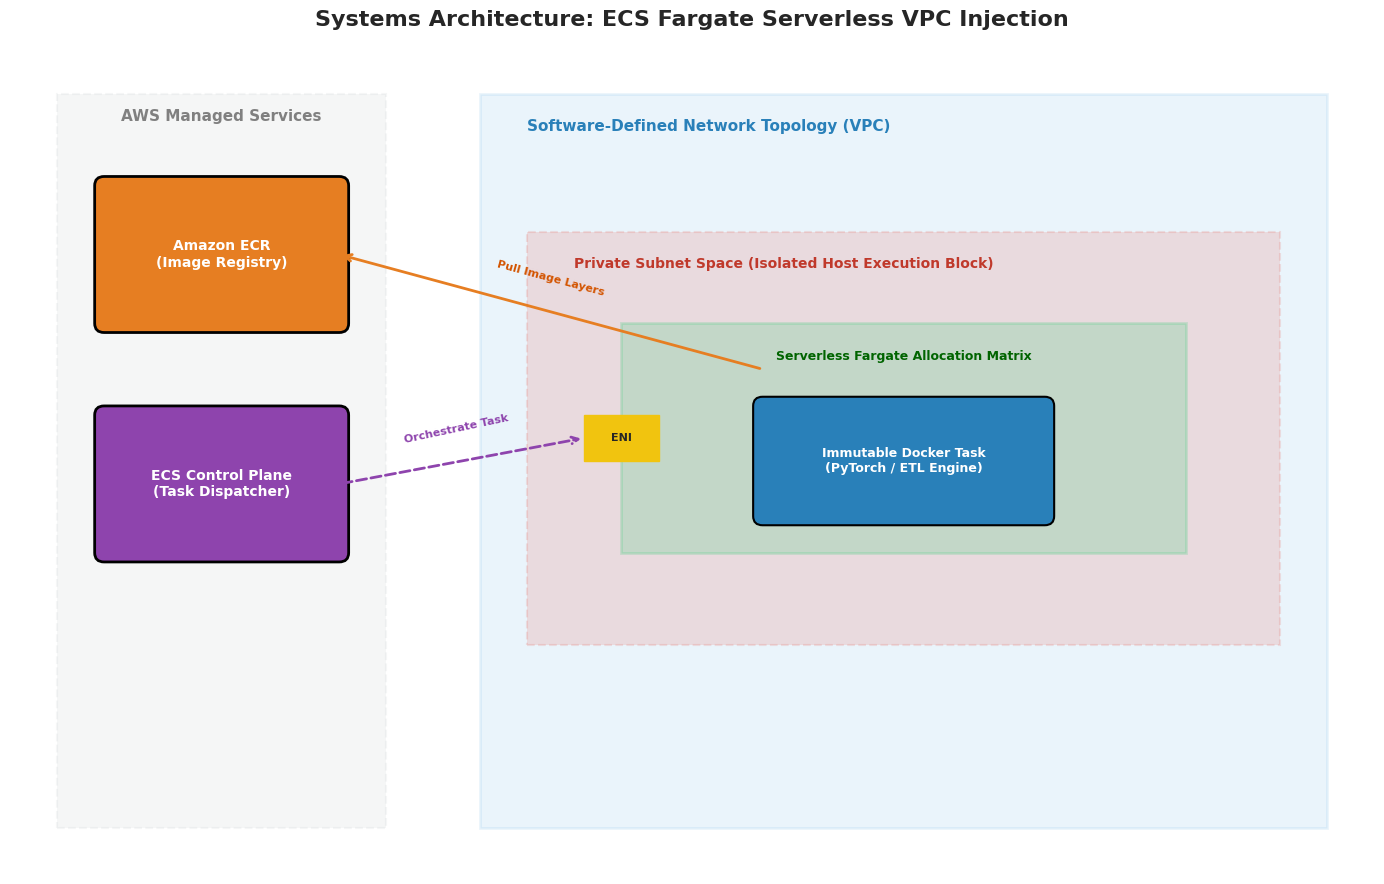

In [7]:
# Visualizing ECS Fargate Network Topology
fig, ax = plt.subplots(figsize=(14, 9))
fig.suptitle("Systems Architecture: ECS Fargate Serverless VPC Injection", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. AWS Managed Services (Control Plane)
aws_cloud_box = patches.Rectangle((0.0, 0.5), 3.5, 8.0, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--')
ax.add_patch(aws_cloud_box)
ax.text(1.75, 8.2, "AWS Managed Services", ha='center', color='gray', fontweight='bold', fontsize=11)

# ECR Storage
ax.add_patch(patches.FancyBboxPatch((0.5, 6.0), 2.5, 1.5, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#e67e22'))
ax.text(1.75, 6.75, "Amazon ECR\n(Image Registry)", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# ECS Control Plane
ax.add_patch(patches.FancyBboxPatch((0.5, 3.5), 2.5, 1.5, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#8e44ad'))
ax.text(1.75, 4.25, "ECS Control Plane\n(Task Dispatcher)", ha='center', va='center', color='white', fontweight='bold', fontsize=10)


# 2. Isolated Target Network Perimeter (The VPC)
vpc_box = patches.Rectangle((4.5, 0.5), 9.0, 8.0, fill=True, color='#3498db', alpha=0.1, edgecolor='black', linewidth=2)
ax.add_patch(vpc_box)
ax.text(5.0, 8.1, "Software-Defined Network Topology (VPC)", ha='left', color='#2980b9', fontweight='bold', fontsize=11)

# Private Subnet Boundary
sub_a_box = patches.Rectangle((5.0, 2.5), 8.0, 4.5, fill=True, color='#e74c3c', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='dashed')
ax.add_patch(sub_a_box)
ax.text(5.5, 6.6, "Private Subnet Space (Isolated Host Execution Block)", ha='left', color='#c0392b', fontweight='bold', fontsize=10)


# 3. Fargate Serverless Compute Tasks
x, y = 6.0, 3.5
ax.add_patch(patches.Rectangle((x, y), 6.0, 2.5, fill=True, color='#2ecc71', alpha=0.2, edgecolor='black', linewidth=2))
ax.text(x + 3.0, y + 2.1, "Serverless Fargate Allocation Matrix", ha='center', color='darkgreen', fontweight='bold', fontsize=9)

# Virtual Interface (ENI)
ax.add_patch(patches.Rectangle((x - 0.4, y + 1.0), 0.8, 0.5, fill=True, color='#f1c40f', edgecolor='black'))
ax.text(x, y + 1.25, "ENI", ha='center', va='center', fontweight='bold', fontsize=8)

# Docker Container Context
ax.add_patch(patches.FancyBboxPatch((x + 1.5, y + 0.4), 3.0, 1.2, boxstyle="round,pad=0.1", linewidth=1.5, edgecolor='black', facecolor='#2980b9'))
ax.text(x + 3.0, y + 1.0, "Immutable Docker Task\n(PyTorch / ETL Engine)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)


# 4. Interprocess Communication Traces
ax.annotate("", xy=(5.6, 4.75), xytext=(3.0, 4.25), arrowprops=dict(arrowstyle="->", lw=2, color="#8e44ad", linestyle="dashed"))
ax.text(4.25, 4.7, "Orchestrate Task", ha='center', fontweight='bold', color="#8e44ad", fontsize=8, rotation=12)

ax.annotate("", xy=(3.0, 6.75), xytext=(7.5, 5.5), arrowprops=dict(arrowstyle="->", lw=2, color="#e67e22"))
ax.text(5.25, 6.3, "Pull Image Layers", ha='center', fontweight='bold', color="#d35400", fontsize=8, rotation=-15)

plt.xlim(-0.5, 14.0)
plt.ylim(0, 9.0)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the difference between AWS Lambda and AWS Fargate like **Using a Shared City Rideshare vs. Building a Specialized Self-Contained Mobile Laboratory**:

* **AWS Lambda (The City Rideshare):** You hail a car. It arrives instantly (Warm Start), drives you 10 minutes down the road, and you step out. It is hyper-efficient for quick, simple, lightweight hops (API events). However, you cannot ask the driver to let you dismantle the backseat to bolt down heavy scientific equipment or host a 3-hour compute session.
* **AWS Fargate (The Leased Mobile Laboratory):** You must run a heavy, complex, 2-hour biological data compilation. You package all your customized runtime components, heavy libraries, and custom processing scripts into a standardized, sealed shipping crate **(The Docker Container)**. You place this crate into a regional storage warehouse **(ECR)**.
* When you trigger your pipeline, the system builds a custom-sized vehicle chassis tailored perfectly to your crate's dimension demands **(The Fargate Resource Vector)**, drops your shipping container onto the flatbed, locks it securely, and wires it directly into your company's secure internal facility gateway **(The VPC ENI Injection)**.
* The container process executes at high velocity, completely unconstrained by short timeouts, and the second the last line of code executes, the entire mobile lab is dismantled automatically, returning billing footprints to zero.